# ELSA Depression Prediction
## Early prediction of depression onset in older English adults

**Module:** AI and Healthcare -- University of Surrey, 2025/26  
**Authors:** Akeeb Lawel, Fiyin Akano, Zannat Chowdhury Sagar, Giridhar Nampally, Pushkar Jadav, Poorna Golla  
**Dataset:** English Longitudinal Study of Ageing (ELSA), UKDS Study 5050 (Banks et al., 2006)

---

### Research questions

**RQ1** -- Can machine learning models trained on ELSA survey data predict depression onset 2 to 4 years in advance in adults aged 50 and over?

**RQ2** -- Does incorporating longitudinal information across two waves improve predictive performance compared to single-wave models, and does prediction horizon length matter?

**RQ3** -- Which feature domains carry independent predictive signal beyond prior depression history?

### Design summary

| Element | Choice |
|---------|--------|
| Outcome | CES-D >= 3 at Wave 8 (Radloff, 1977; Steffick, 2000) |
| Prediction arms | W6 only, W7 only, W6+W7 combined |
| Feature configs | 5 per arm (full, no prior CES-D, health, function/cognition, socioeconomic) |
| Models | Logistic Regression, Random Forest, XGBoost, LightGBM |
| Primary metric | ROC-AUC (discrimination); binary F1 and recall for clinical framing |
| Validation | Stratified 5-fold CV + 25% held-out test set |

> **CES-D note:** we use the IFS-validated `cesd_sc` variable (0-8 scale, binary item scoring) rather than reconstructed PSced items. Reconstruction via `psced_items_as_0_to_3` incorrectly treats binary items as Likert-scaled, producing a 8-16 range and ~74% apparent prevalence. The IFS-derived score gives the epidemiologically correct ~19% prevalence (Steffick, 2000).


---
## 0. Setup

### 0.1 Set your data path

Paste the path to your ELSA data below. This can be:
- A path to the downloaded UKDS zip file (e.g. `UKDA-5050-stata.zip`)
- A path to the extracted folder at any level (the notebook will find `stata13_se` automatically)

In [17]:
# ── SET THIS PATH BEFORE RUNNING ─────────────────────────────────────────────
ELSA_PATH = "/content/drive/MyDrive/ELSA"
# ─────────────────────────────────────────────────────────────────────────────


### 0.2 Dependencies

In [18]:
import importlib, subprocess, sys

# Install common packages
for pkg in ["pyreadstat", "shap"]:
    if importlib.util.find_spec(pkg) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

# Ensure xgboost[cuda] is installed
print("Ensuring xgboost[cuda] is installed...")
subprocess.check_call([sys.executable, "-m", "pip", "uninstall", "-y", "xgboost"])
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "xgboost[cuda]"])

# Install lightgbm (Colab often installs a GPU-compatible version if device='gpu' is set)
if importlib.util.find_spec("lightgbm") is None:
    print("Installing lightgbm...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "lightgbm"])

print("Dependencies OK")

Ensuring xgboost[cuda] is installed...
Dependencies OK


### 0.3 Colab drive mount

In [19]:
from pathlib import Path
import sys

if Path("/content").exists():
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 0.4 Imports and constants

In [20]:
import warnings, copy, zipfile
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from scipy.stats import randint, uniform

from sklearn.model_selection  import (train_test_split, StratifiedKFold,
                                       cross_validate, RandomizedSearchCV)
from sklearn.pipeline          import Pipeline
from sklearn.impute            import SimpleImputer
from sklearn.preprocessing     import StandardScaler
from sklearn.linear_model      import LogisticRegression
from sklearn.ensemble          import RandomForestClassifier
from sklearn.calibration       import calibration_curve, CalibratedClassifierCV
from sklearn.metrics           import (roc_auc_score, roc_curve,
                                       precision_recall_curve,
                                       average_precision_score,
                                       f1_score, precision_score,
                                       recall_score, accuracy_score,
                                       classification_report,
                                       confusion_matrix, ConfusionMatrixDisplay)
from xgboost    import XGBClassifier
from lightgbm   import LGBMClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

SEED         = 42
CESD_CUTOFF  = 3
SURVEY_MISS  = {-1, -2, -8, -9}
N_ITER_TUNE  = 30
CV_FOLDS     = 5


### 0.5 Path detection and output directories

In [21]:
def locate_stata_dir(user_path: str) -> Path:
    """
    Accept a zip file, any parent directory, or the stata13_se folder directly.
    Returns the Path to the folder containing wave_*_elsa_data*.dta files.
    """
    p = Path(user_path).expanduser()

    if not p.exists():
        raise FileNotFoundError(f"Path not found: {p}")

    # Already pointing at or inside the data folder
    if p.is_dir():
        dta = list(p.glob("wave_6_elsa_data*.dta"))
        if dta:
            return p
        # Search downward
        matches = list(p.rglob("stata13_se"))
        if matches:
            return matches[0]
        # Fallback: find any wave file
        dta_deep = list(p.rglob("wave_6_elsa_data*.dta"))
        if dta_deep:
            return dta_deep[0].parent

    # Zip file
    if p.suffix.lower() == ".zip":
        extract_to = Path("/content/elsa_extracted")
        print(f"Extracting {p.name} ...")
        with zipfile.ZipFile(p, "r") as z:
            z.extractall(extract_to)
        matches = list(extract_to.rglob("stata13_se"))
        if matches:
            return matches[0]
        dta = list(extract_to.rglob("wave_6_elsa_data*.dta"))
        if dta:
            return dta[0].parent

    raise FileNotFoundError(
        f"Could not locate ELSA data files from: {user_path}\n"
        "Ensure the path points to the UKDS zip download or extracted folder."
    )


BASE = locate_stata_dir(ELSA_PATH)
print(f"Data root: {BASE}")

# Verify key files exist
required = [
    "wave_6_elsa_data_v2.dta", "wave_7_elsa_data.dta",
    "wave_8_elsa_data_eul_v2.dta",
    "wave_6_ifs_derived_variables.dta",
    "wave_7_ifs_derived_variables.dta",
    "wave_8_ifs_derived_variables.dta",
    "wave_6_financial_derived_variables.dta",
    "wave_7_financial_derived_variables.dta",
]
missing = [f for f in required if not (BASE / f).exists()]
if missing:
    print("WARNING -- missing files:", missing)
else:
    print("All required files found.")

# File path helpers
CORE = {6: BASE/"wave_6_elsa_data_v2.dta",
        7: BASE/"wave_7_elsa_data.dta",
        8: BASE/"wave_8_elsa_data_eul_v2.dta"}
IFS  = {6: BASE/"wave_6_ifs_derived_variables.dta",
        7: BASE/"wave_7_ifs_derived_variables.dta",
        8: BASE/"wave_8_ifs_derived_variables.dta"}
FIN  = {6: BASE/"wave_6_financial_derived_variables.dta",
        7: BASE/"wave_7_financial_derived_variables.dta"}

# Output directories
OUT_ROOT  = Path("/content/outputs")
FIG_DIRS  = {k: OUT_ROOT/"figures"/k for k in
             ["01_data","02_experiments","03_results","04_interpretation","05_sensitivity"]}
RES_DIR   = OUT_ROOT / "results"
for d in list(FIG_DIRS.values()) + [RES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Outputs: {OUT_ROOT}")


Data root: /content/drive/MyDrive/ELSA/data/UKDA-5050-stata/stata/stata13_se
All required files found.
Outputs: /content/outputs


---
## 1. Data Loading

We load IFS derived variables, core interview data, and financial derived variables for Waves 6, 7, and 8, merging on `idauniq`. Only participants present in all three waves are retained (inner join). Wave 8 provides the outcome label only.

ELSA collects data at two-year intervals. The audit (Akeeb et al.) confirmed that Waves 6, 7, and 8 have the highest participant overlap (>90% consecutive retention) and consistent CES-D availability (>93% valid responses), making them the optimal window for this study.


In [22]:
IFS_COLS = [
    "idauniq", "age", "sex", "nonwhite", "marstat", "couple",
    "srh_hrs", "llsill", "hlimwrk",
    "hemobwa","hemobsi","hemobch","hemobcs","hemobcl",
    "hemobst","hemobre","hemobpu","hemobli","hemobpi","hemob96",
    "headldr","headlwa","headlba","headlea","headlbe","headlwc",
    "headlma","headlda","headlpr","headlsh","headlph",
    "headlco","headlme","headlho","headlmo","headl96",
    "memtotb","execnn",
    "ecpos","qual3",
    "findiff","ndepriv","lackresb",
    "famtype","tenure","nsibs","ngrandch","smokerstat",
    "cesd_sc","cesd_na",
]
CORE_COLS = [
    "idauniq",
    "Hehelf","Heill",
    "HeActa","HeActb","HeActc",
    "hediabp","hediadi","hediami","hediast","hediahf","hediaar","hediaan",
    "scint","chinhh","chouthh",
]
FIN_COLS = ["idauniq","totwq5_bu_s"]


def load_wave(wave: int, suffix: str) -> pd.DataFrame:
    ifs  = pd.read_stata(str(IFS[wave]),  convert_categoricals=False, columns=IFS_COLS)
    core = pd.read_stata(str(CORE[wave]), convert_categoricals=False, columns=CORE_COLS)
    fin  = pd.read_stata(str(FIN[wave]),  convert_categoricals=False, columns=FIN_COLS)
    df = ifs.merge(core, on="idauniq", how="inner").merge(fin, on="idauniq", how="left")
    df.columns = [c.lower() for c in df.columns]
    rename = {c: f"{c}_{suffix}" for c in df.columns if c != "idauniq"}
    return df.rename(columns=rename)


print("Loading waves...")
w6 = load_wave(6, "w6")
w7 = load_wave(7, "w7")
print(f"  Wave 6: {len(w6):,} rows, {w6.shape[1]-1} features")
print(f"  Wave 7: {len(w7):,} rows, {w7.shape[1]-1} features")

w8_ifs = pd.read_stata(str(IFS[8]), convert_categoricals=False,
                        columns=["idauniq","cesd_sc","cesd_na"])
w8_ifs.columns = [c.lower() for c in w8_ifs.columns]
w8_ifs = w8_ifs.rename(columns={"cesd_sc":"cesd_sc_w8","cesd_na":"cesd_na_w8"})
print(f"  Wave 8 (outcome only): {len(w8_ifs):,} rows")

panel = w6.merge(w7, on="idauniq", how="inner").merge(w8_ifs, on="idauniq", how="inner")
print(f"\nLongitudinal panel (inner join W6+W7+W8): {len(panel):,} participants")


Loading waves...
  Wave 6: 10,601 rows, 65 features
  Wave 7: 9,666 rows, 65 features
  Wave 8 (outcome only): 8,445 rows

Longitudinal panel (inner join W6+W7+W8): 7,535 participants


### 1.1 Outcome variable

The CES-D (Center for Epidemiologic Studies Depression Scale) is an 8-item binary questionnaire. Each item is answered yes or no, giving a total score of 0 to 8. A threshold of >= 3 is the standard cutoff for clinically significant depressive symptoms in ELSA (Steffick, 2000), yielding a prevalence consistent with epidemiological estimates for English adults aged 50 and over (15 to 25%).

We use the IFS-validated `cesd_sc` variable directly, which avoids the scoring artefact that arises when reconstructing the sum from raw PSced items.


Analytic sample:   7,211 participants
Depressed (>=3):   1,372 (19.0%)
Not depressed:     5,839 (81.0%)
Class ratio:       1:4.3


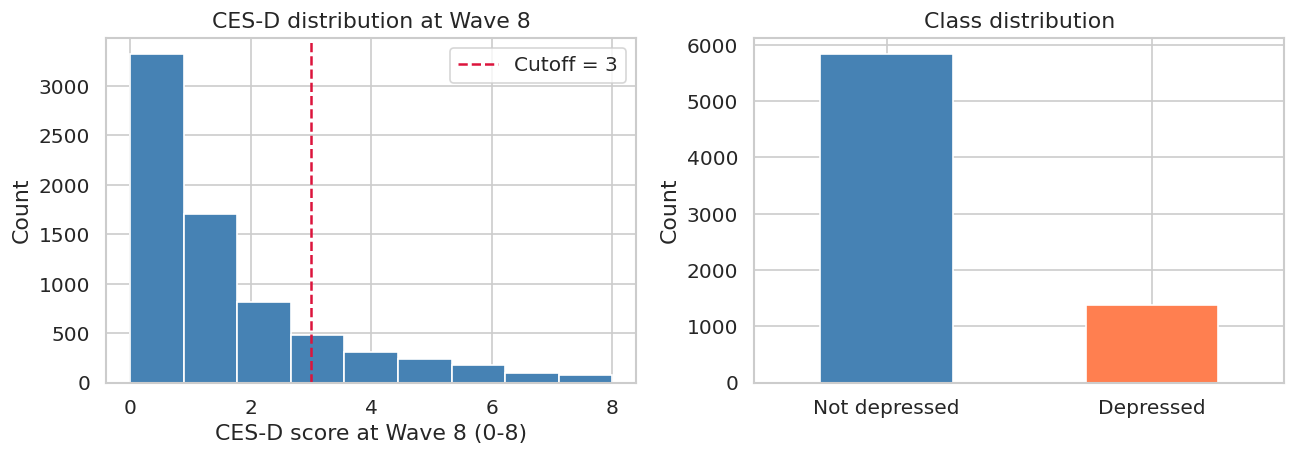

In [23]:
panel = panel[~panel["cesd_sc_w8"].isin(SURVEY_MISS)].copy()
panel = panel.dropna(subset=["cesd_sc_w8"])
panel["depressed_w8"] = (panel["cesd_sc_w8"] >= CESD_CUTOFF).astype(int)

n_dep = panel["depressed_w8"].sum()
prev  = n_dep / len(panel)

print(f"Analytic sample:   {len(panel):,} participants")
print(f"Depressed (>=3):   {n_dep:,} ({prev:.1%})")
print(f"Not depressed:     {len(panel)-n_dep:,} ({1-prev:.1%})")
print(f"Class ratio:       1:{(len(panel)-n_dep)/n_dep:.1f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
panel["cesd_sc_w8"].hist(bins=9, ax=axes[0], color="steelblue", edgecolor="white")
axes[0].axvline(CESD_CUTOFF, color="crimson", ls="--", lw=1.5, label=f"Cutoff = {CESD_CUTOFF}")
axes[0].set(xlabel="CES-D score at Wave 8 (0-8)", ylabel="Count",
            title="CES-D distribution at Wave 8")
axes[0].legend()
panel["depressed_w8"].value_counts().sort_index().plot.bar(
    ax=axes[1], color=["steelblue","coral"], edgecolor="white")
axes[1].set(xticklabels=["Not depressed","Depressed"], xlabel="",
            ylabel="Count", title="Class distribution")
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIRS["01_data"]/"outcome_distribution.png", bbox_inches="tight")
plt.show()


---
## 2. Preprocessing

### 2.1 Survey missing code recoding and wave-symmetry enforcement

ELSA uses numeric codes -1, -2, -8, and -9 for non-responses (inapplicable, unknown, refusal). These are recoded to NaN.

Columns with more than 40% missing are dropped, with missingness estimated on the training partition only to avoid leakage. Wave symmetry is then enforced: if a stem is dropped at one wave, it is removed from both. This ensures the longitudinal model (Arm 3) never uses a predictor that is partially available across time, which would produce an inconsistent measure across participants.


In [24]:
exclude = {"idauniq","cesd_sc_w8","cesd_na_w8","depressed_w8"}
predictor_cols = [c for c in panel.columns if c not in exclude]

for col in predictor_cols:
    panel[col] = pd.to_numeric(panel[col], errors="coerce")
    panel.loc[panel[col].isin(SURVEY_MISS), col] = np.nan

# Missingness on training split only
_Xm, _, _, _ = train_test_split(panel[predictor_cols], panel["depressed_w8"],
                                 test_size=0.25, stratify=panel["depressed_w8"],
                                 random_state=SEED)
miss_pct  = _Xm.isna().mean().sort_values(ascending=False)
high_miss = miss_pct[miss_pct > 0.40].index.tolist()
print(f"Dropped (>40% missing): {high_miss}")
predictor_cols = [c for c in predictor_cols if c not in high_miss]

# Wave-symmetry enforcement
def _stem(col):
    for sfx in ("_w6","_w7","_w8"):
        if col.endswith(sfx): return col[:-3]
    return col

dropped_stems = {_stem(c) for c in high_miss}
also_drop     = [c for c in predictor_cols if _stem(c) in dropped_stems]
if also_drop:
    print(f"Wave-symmetry: also dropping {also_drop}")
    predictor_cols = [c for c in predictor_cols if c not in also_drop]

print(f"Predictor columns remaining: {len(predictor_cols)}")


Dropped (>40% missing): ['ndepriv_w7']
Wave-symmetry: also dropping ['ndepriv_w6']
Predictor columns remaining: 128


### 2.2 Feature engineering

Composite counts reduce correlated item batteries to single interpretable scores. Trajectory features capture change between waves, which Jadav et al. identified as having high predictive value for depression onset.

In [25]:
MOBILITY_ITEMS = ["hemobwa","hemobsi","hemobch","hemobcs","hemobcl",
                  "hemobst","hemobre","hemobpu","hemobli","hemobpi"]
ADL_ITEMS      = ["headldr","headlwa","headlba","headlea","headlbe","headlwc"]
IADL_ITEMS     = ["headlma","headlda","headlpr","headlsh","headlph",
                  "headlco","headlme","headlho","headlmo"]

def safe_sum(df, items, sfx):
    cols    = [f"{i}_{sfx}" for i in items]
    present = [c for c in cols if c in df.columns]
    return df[present].sum(axis=1, min_count=1) if present else pd.Series(np.nan, index=df.index)

for sfx in ["w6","w7"]:
    panel[f"mobility_count_{sfx}"]    = safe_sum(panel, MOBILITY_ITEMS, sfx)
    panel[f"adl_count_{sfx}"]         = safe_sum(panel, ADL_ITEMS,      sfx)
    panel[f"iadl_count_{sfx}"]        = safe_sum(panel, IADL_ITEMS,     sfx)
    panel[f"functional_burden_{sfx}"] = (panel[f"adl_count_{sfx}"]
                                         + panel[f"iadl_count_{sfx}"])

# Trajectory features (W6+W7 arm only)
panel["cesd_change"]     = panel["cesd_sc_w7"]         - panel["cesd_sc_w6"]
panel["mobility_change"] = panel["mobility_count_w7"]  - panel["mobility_count_w6"]

ENG_W6   = [f"mobility_count_w6","adl_count_w6","iadl_count_w6","functional_burden_w6"]
ENG_W7   = [f"mobility_count_w7","adl_count_w7","iadl_count_w7","functional_burden_w7"]
ENG_BOTH = ENG_W6 + ENG_W7 + ["cesd_change","mobility_change"]

print("Feature engineering complete.")
for f in ENG_W6 + ["cesd_change","mobility_change"]:
    v = panel[f].dropna()
    print(f"  {f}: mean={v.mean():.2f}, range=[{v.min():.0f},{v.max():.0f}]")


Feature engineering complete.
  mobility_count_w6: mean=1.68, range=[0,10]
  adl_count_w6: mean=0.28, range=[0,6]
  iadl_count_w6: mean=0.30, range=[0,9]
  functional_burden_w6: mean=0.57, range=[0,15]
  cesd_change: mean=0.02, range=[-8,8]
  mobility_change: mean=0.07, range=[-9,9]


---
## 3. Experimental Design

### 3.1 Three prediction arms

Each arm represents a different temporal setup. Comparing arms directly answers **RQ2**.

| Arm | Predictors | Horizon |
|-----|-----------|---------|
| W6 only | Wave 6 features | ~4 years before W8 |
| W7 only | Wave 7 features | ~2 years before W8 |
| W6+W7 combined | Both waves + change features | 2 to 4 years |


In [26]:
# Base predictor sets per arm (clean stems only, no engineered yet)
base_w6   = [c for c in predictor_cols if c.endswith("_w6")]
base_w7   = [c for c in predictor_cols if c.endswith("_w7")]
base_both = base_w6 + base_w7

arm1_cols = list(dict.fromkeys(base_w6   + ENG_W6))
arm2_cols = list(dict.fromkeys(base_w7   + ENG_W7))
arm3_cols = list(dict.fromkeys(base_both + ENG_BOTH))

ARM_COLS  = {"W6 only": arm1_cols, "W7 only": arm2_cols, "W6+W7": arm3_cols}

for name, cols in ARM_COLS.items():
    print(f"  {name:10s}: {len(cols)} features")


  W6 only   : 68 features
  W7 only   : 68 features
  W6+W7     : 138 features


### 3.2 Feature configurations

Five configs run on every arm. Config names and column selection are constructed dynamically from whichever arm's predictor set is active.


In [27]:
def build_configs(cols):
    """Return named feature subsets for a given arm's predictor column list."""
    def match(c, patterns):
        cl = c.lower()
        return any(p in cl for p in patterns)

    prior_dep  = [c for c in cols if "cesd" in c.lower()]
    health_srh = [c for c in cols if match(c, ["hehelf","heill","srh_hrs","llsill","hlimwrk"])]
    chronic    = [c for c in cols if c.lower().startswith("hedia")]
    mobility   = [c for c in cols if match(c, ["mobility","adl_count","iadl_count",
                                                "functional_burden","hemob96","headl96"])]
    cognition  = [c for c in cols if match(c, ["memtotb","execnn"])]
    socio      = [c for c in cols if match(c, ["ecpos","qual3","findiff",
                                                "lackres","totwq5"])]
    social     = [c for c in cols if match(c, ["famtype","tenure","nsibs","ngrandch",
                                                "chinhh","chouthh","smokerstat"])]
    return {
        "full":           cols,
        "no_cesd":        [c for c in cols if c not in prior_dep],
        "health_only":    health_srh + chronic,
        "function_cog":   mobility   + cognition,
        "socioeconomic":  socio      + social,
    }

# Verify
for arm_name, arm_cols in ARM_COLS.items():
    cfgs = build_configs(arm_cols)
    print(f"{arm_name}:")
    for cfg_name, cfg_cols in cfgs.items():
        print(f"  {cfg_name:16s}: {len(cfg_cols)} features")


W6 only:
  full            : 68 features
  no_cesd         : 66 features
  health_only     : 12 features
  function_cog    : 8 features
  socioeconomic   : 12 features
W7 only:
  full            : 68 features
  no_cesd         : 66 features
  health_only     : 12 features
  function_cog    : 8 features
  socioeconomic   : 12 features
W6+W7:
  full            : 138 features
  no_cesd         : 133 features
  health_only     : 24 features
  function_cog    : 17 features
  socioeconomic   : 24 features


### 3.3 Model factory

All four models handle class imbalance explicitly. LightGBM is included as the literature benchmark; Zhao et al. (2025) found it achieved AUC = 0.90 on ELSA in a cross-sectional study using a similar feature set.

In [28]:
def make_models(pos_weight: int):
    """Return fresh unfitted pipelines. Call once per arm to avoid state sharing."""
    return {
        "LR": Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("scl", StandardScaler()),
            ("clf", LogisticRegression(max_iter=5000, class_weight="balanced",
                                       random_state=SEED, solver="lbfgs")),
        ]),
        "RF": Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("clf", RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                           max_depth=15, min_samples_leaf=10,
                                           random_state=SEED, n_jobs=-1)),
        ]),
        "XGB": Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("clf", XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05,
                                  scale_pos_weight=pos_weight,
                                  random_state=SEED, eval_metric="logloss",
                                  verbosity=0, n_jobs=-1, tree_method='auto')),
        ]),
        "LGBM": Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("clf", LGBMClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                                   class_weight="balanced", min_child_samples=20,
                                   random_state=SEED, n_jobs=-1, verbose=-1,
                                   device='gpu')),
        ]),
    }

### 3.4 Train / test split

One stratified 80/20 split is applied per arm on the same participant rows. Using identical participant partitions across arms ensures results are directly comparable.

In [29]:
def split_arm(arm_cols, panel, seed=SEED):
    X = panel[arm_cols].copy()
    y = panel["depressed_w8"].copy()
    return train_test_split(X, y, test_size=0.25, stratify=y, random_state=seed)

splits = {}
for arm_name, arm_cols in ARM_COLS.items():
    X_tr, X_te, y_tr, y_te = split_arm(arm_cols, panel)
    splits[arm_name] = (X_tr, X_te, y_tr, y_te)
    print(f"{arm_name:10s}: train={len(X_tr):,} ({y_tr.mean():.1%} depressed)  test={len(X_te):,}")


W6 only   : train=5,408 (19.0% depressed)  test=1,803
W7 only   : train=5,408 (19.0% depressed)  test=1,803
W6+W7     : train=5,408 (19.0% depressed)  test=1,803


---
## 4. Experiment -- all arms x all configs x all models

Every combination is trained on the arm's training set and evaluated on its held-out test set. The same four metrics are recorded for all runs.

Primary metric for model selection is ROC-AUC. Binary F1 (positive class only) is the primary clinical metric -- it captures how well the model detects depression specifically, without inflating the score by rewarding majority-class performance.


In [30]:
def eval_pipe(pipe, X_te, y_te):
    y_pred  = pipe.predict(X_te)
    y_proba = pipe.predict_proba(X_te)[:, 1]
    return {
        "AUC":       round(roc_auc_score(y_te, y_proba),           4),
        "F1_binary": round(f1_score(y_te, y_pred, average="binary"),4),
        "F1_macro":  round(f1_score(y_te, y_pred, average="macro"), 4),
        "Recall":    round(recall_score(y_te, y_pred),              4),
        "Precision": round(precision_score(y_te, y_pred),           4),
        "Avg_Prec":  round(average_precision_score(y_te, y_proba),  4),
    }


all_results   = []
fitted_store  = {}  # (arm, config, model) -> fitted pipeline

for arm_name, arm_cols in ARM_COLS.items():
    X_tr, X_te, y_tr, y_te = splits[arm_name]
    pw = int((y_tr == 0).sum() / (y_tr == 1).sum())
    configs = build_configs(arm_cols)

    for cfg_name, cfg_cols in configs.items():
        cfg_cols = [c for c in cfg_cols if c in X_tr.columns]
        if not cfg_cols:
            continue
        for model_name, pipe in make_models(pw).items():
            pipe.fit(X_tr[cfg_cols], y_tr)
            fitted_store[(arm_name, cfg_name, model_name)] = (pipe, cfg_cols)
            m = eval_pipe(pipe, X_te[cfg_cols], y_te)
            all_results.append({"arm": arm_name, "config": cfg_name,
                                 "model": model_name, "n_features": len(cfg_cols), **m})
            print(f"  {arm_name:10s} | {cfg_name:16s} | {model_name:5s} | "
                  f"AUC={m['AUC']:.4f}  F1b={m['F1_binary']:.4f}")

results_df = pd.DataFrame(all_results)
results_df.to_csv(RES_DIR/"all_experiments.csv", index=False)
print("\nSaved: all_experiments.csv")


  W6 only    | full             | LR    | AUC=0.8076  F1b=0.5208
  W6 only    | full             | RF    | AUC=0.8106  F1b=0.5277
  W6 only    | full             | XGB   | AUC=0.8040  F1b=0.5191
  W6 only    | full             | LGBM  | AUC=0.7875  F1b=0.5099
  W6 only    | no_cesd          | LR    | AUC=0.7546  F1b=0.4606
  W6 only    | no_cesd          | RF    | AUC=0.7605  F1b=0.4754
  W6 only    | no_cesd          | XGB   | AUC=0.7329  F1b=0.4550
  W6 only    | no_cesd          | LGBM  | AUC=0.7386  F1b=0.4373
  W6 only    | health_only      | LR    | AUC=0.7125  F1b=0.4391
  W6 only    | health_only      | RF    | AUC=0.7208  F1b=0.4409
  W6 only    | health_only      | XGB   | AUC=0.7132  F1b=0.4398
  W6 only    | health_only      | LGBM  | AUC=0.7139  F1b=0.4440
  W6 only    | function_cog     | LR    | AUC=0.7200  F1b=0.4510
  W6 only    | function_cog     | RF    | AUC=0.7200  F1b=0.4552
  W6 only    | function_cog     | XGB   | AUC=0.7022  F1b=0.4420
  W6 only    | function_c

### 4.1 AUC comparison charts per arm

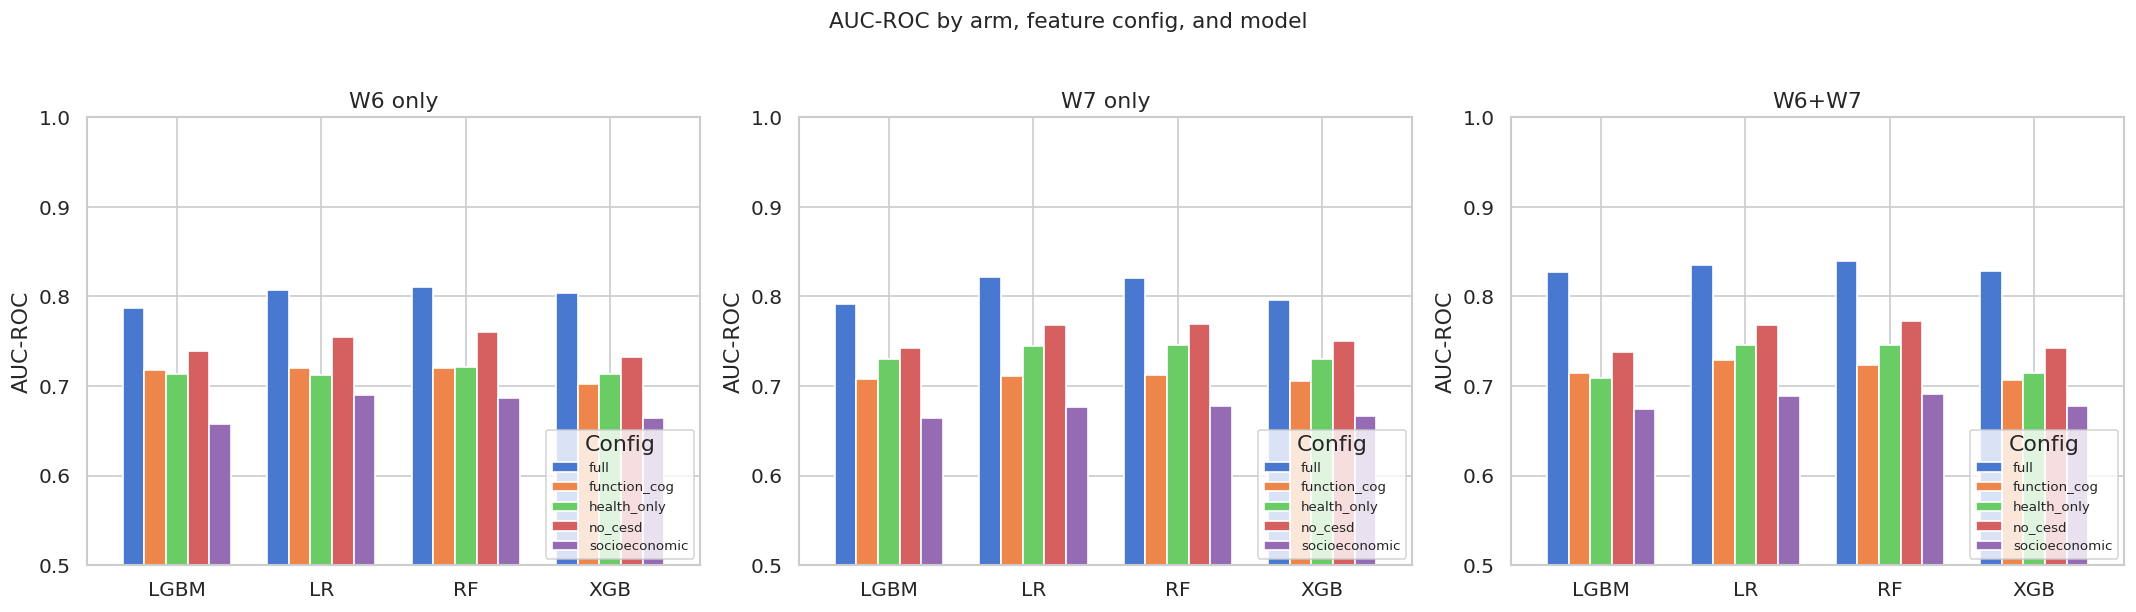

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
arm_labels = list(ARM_COLS.keys())

for ax, arm_name in zip(axes, arm_labels):
    sub = results_df[results_df["arm"] == arm_name]
    pivot = sub.pivot_table(index="model", columns="config", values="AUC")
    pivot.plot.bar(ax=ax, edgecolor="white", width=0.75)
    ax.set_ylim(0.5, 1.0)
    ax.set_title(arm_name)
    ax.set_xlabel("")
    ax.set_ylabel("AUC-ROC")
    ax.tick_params(axis="x", rotation=0)
    ax.legend(title="Config", fontsize=8, loc="lower right")

plt.suptitle("AUC-ROC by arm, feature config, and model", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIRS["02_experiments"]/"auc_all_arms_configs.png", bbox_inches="tight")
plt.show()


---
## 5. Hyperparameter Tuning

For each arm, we select the best-performing feature config by mean AUC across all models, then run RandomizedSearchCV (Bergstra and Bengio, 2012) on RF, XGB, and LGBM. LR is excluded from tuning as its hyperparameter space is narrow and its role here is as an interpretable linear baseline.

Tuning uses stratified 5-fold CV on the training set only. The held-out test set is untouched.


In [32]:
def best_config_for_arm(results_df, arm_name):
    sub = results_df[results_df["arm"] == arm_name]
    return sub.groupby("config")["AUC"].mean().idxmax()

tuned_results = []
tuned_store   = {}  # (arm, model) -> best fitted pipeline

cv_tune = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)

RF_PARAMS = {
    "clf__n_estimators":    randint(200, 600),
    "clf__max_depth":       [6, 8, 10, 12, 15, None],
    "clf__min_samples_leaf":randint(5, 25),
    "clf__max_features":    ["sqrt", "log2", 0.3, 0.5],
}
XGB_PARAMS = {
    "clf__n_estimators":     randint(200, 600),
    "clf__max_depth":        randint(3, 8),
    "clf__learning_rate":    uniform(0.02, 0.15),
    "clf__subsample":        uniform(0.6, 0.4),
    "clf__colsample_bytree": uniform(0.5, 0.5),
    "clf__reg_alpha":        uniform(0, 2),
    "clf__reg_lambda":       uniform(0.5, 2),
}
LGBM_PARAMS = {
    "clf__n_estimators":     randint(200, 600),
    "clf__max_depth":        randint(3, 10),
    "clf__learning_rate":    uniform(0.02, 0.15),
    "clf__num_leaves":       randint(20, 80),
    "clf__min_child_samples":randint(10, 40),
    "clf__subsample":        uniform(0.6, 0.4),
    "clf__colsample_bytree": uniform(0.5, 0.5),
    "clf__reg_alpha":        uniform(0, 1),
    "clf__reg_lambda":       uniform(0, 1),
}


for arm_name, arm_cols in ARM_COLS.items():
    best_cfg  = best_config_for_arm(results_df, arm_name)
    cfg_cols  = [c for c in build_configs(arm_cols)[best_cfg]
                 if c in panel.columns]
    X_tr, X_te, y_tr, y_te = splits[arm_name]
    X_tr_c, X_te_c = X_tr[cfg_cols], X_te[cfg_cols]
    pw = int((y_tr == 0).sum() / (y_tr == 1).sum())
    print(f"\n{arm_name} -- best config: {best_cfg} ({len(cfg_cols)} features)")

    models_to_tune = {
        "RF":   (make_models(pw)["RF"],  RF_PARAMS),
        "XGB":  (make_models(pw)["XGB"], XGB_PARAMS),
        "LGBM": (make_models(pw)["LGBM"],LGBM_PARAMS),
    }

    # Include untuned LR for reference
    lr_pipe = make_models(pw)["LR"]
    lr_pipe.fit(X_tr_c, y_tr)
    tuned_store[(arm_name, "LR")] = (lr_pipe, cfg_cols)
    m = eval_pipe(lr_pipe, X_te_c, y_te)
    tuned_results.append({"arm": arm_name, "model": "LR (baseline)",
                           "config": best_cfg, **m})
    print(f"  LR (baseline):  AUC={m['AUC']:.4f}")

    for model_name, (pipe, param_dist) in models_to_tune.items():
        search = RandomizedSearchCV(pipe, param_dist, n_iter=N_ITER_TUNE,
                                    scoring="roc_auc", cv=cv_tune,
                                    random_state=SEED, n_jobs=-1, refit=True)
        search.fit(X_tr_c, y_tr)
        best_pipe = search.best_estimator_
        tuned_store[(arm_name, model_name)] = (best_pipe, cfg_cols)
        m = eval_pipe(best_pipe, X_te_c, y_te)
        tuned_results.append({"arm": arm_name, "model": f"{model_name} (tuned)",
                               "config": best_cfg, **m})
        print(f"  {model_name} (tuned): AUC={m['AUC']:.4f}  CV best={search.best_score_:.4f}")

tuned_df = pd.DataFrame(tuned_results)
tuned_df.to_csv(RES_DIR/"tuned_models.csv", index=False)
print("\nSaved: tuned_models.csv")



W6 only -- best config: full (68 features)
  LR (baseline):  AUC=0.8076
  RF (tuned): AUC=0.8155  CV best=0.8159
  XGB (tuned): AUC=0.8165  CV best=0.8117
  LGBM (tuned): AUC=0.8192  CV best=0.8163

W7 only -- best config: full (68 features)
  LR (baseline):  AUC=0.8212
  RF (tuned): AUC=0.8241  CV best=0.8292
  XGB (tuned): AUC=0.8188  CV best=0.8205
  LGBM (tuned): AUC=0.8231  CV best=0.8271

W6+W7 -- best config: full (138 features)
  LR (baseline):  AUC=0.8349
  RF (tuned): AUC=0.8483  CV best=0.8451
  XGB (tuned): AUC=0.8438  CV best=0.8372
  LGBM (tuned): AUC=0.8430  CV best=0.8432

Saved: tuned_models.csv


---
## 6. Results and Comparison

This section answers **RQ1** and **RQ2** directly through cross-arm comparison.


### 6.1 Summary table

In [33]:
print("=== Tuned model results by arm ===\n")
print(tuned_df[["arm","model","AUC","F1_binary","F1_macro","Recall","Precision"]]
      .to_string(index=False))
print()
print("Metric note:")
print("  AUC-ROC    -- primary discrimination metric (threshold-independent)")
print("  F1_binary  -- F1 for the depressed class only (clinical detection rate)")
print("  F1_macro   -- unweighted mean across both classes")
print("  Recall     -- fraction of depressed cases correctly identified")


=== Tuned model results by arm ===

    arm         model    AUC  F1_binary  F1_macro  Recall  Precision
W6 only LR (baseline) 0.8076     0.5208    0.6790  0.6939     0.4168
W6 only    RF (tuned) 0.8155     0.5298    0.6916  0.6618     0.4416
W6 only   XGB (tuned) 0.8165     0.5336    0.6885  0.7055     0.4291
W6 only  LGBM (tuned) 0.8192     0.5323    0.6834  0.7318     0.4183
W7 only LR (baseline) 0.8212     0.5413    0.7016  0.6589     0.4593
W7 only    RF (tuned) 0.8241     0.5452    0.7036  0.6676     0.4608
W7 only   XGB (tuned) 0.8188     0.5381    0.7017  0.6385     0.4650
W7 only  LGBM (tuned) 0.8231     0.5397    0.6982  0.6735     0.4503
  W6+W7 LR (baseline) 0.8349     0.5591    0.7110  0.6968     0.4668
  W6+W7    RF (tuned) 0.8483     0.5819    0.7273  0.7143     0.4910
  W6+W7   XGB (tuned) 0.8438     0.5851    0.7341  0.6764     0.5156
  W6+W7  LGBM (tuned) 0.8430     0.5771    0.7181  0.7580     0.4659

Metric note:
  AUC-ROC    -- primary discrimination metric (thresh

### 6.2 Cross-arm AUC comparison (answers RQ2)

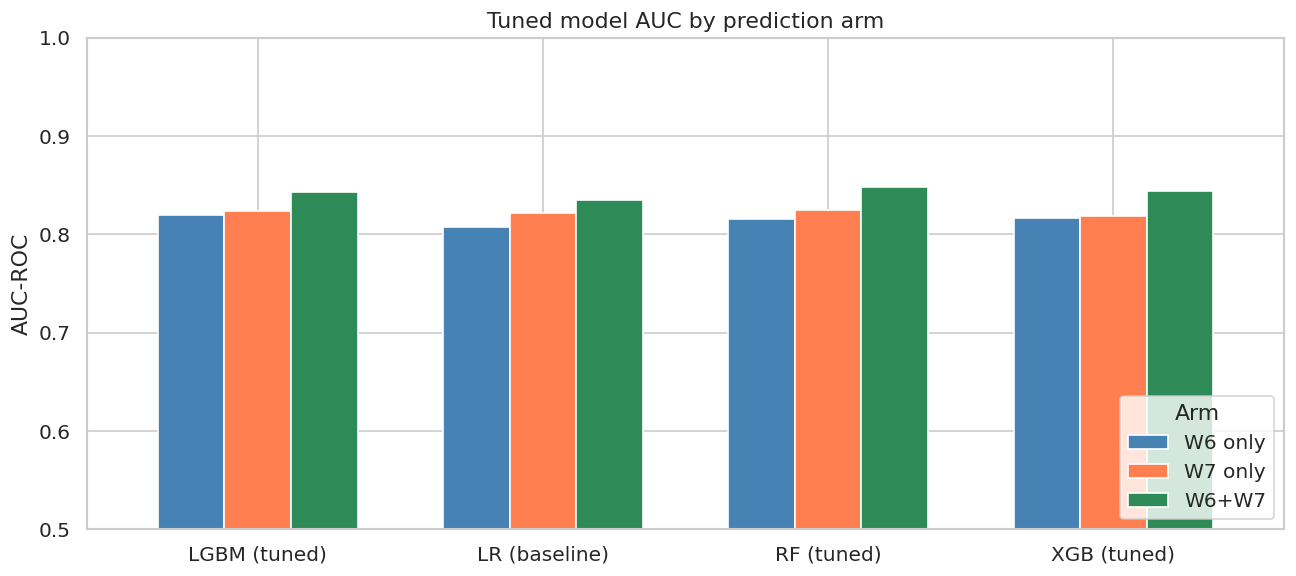

In [34]:
best_per_arm = (tuned_df.groupby(["arm","model"])["AUC"]
                .mean().reset_index()
                .sort_values(["arm","AUC"], ascending=[True,False]))

fig, ax = plt.subplots(figsize=(11, 5))
pivot = tuned_df.pivot_table(index="model", columns="arm", values="AUC")
pivot[list(ARM_COLS.keys())].plot.bar(ax=ax, edgecolor="white", width=0.7,
                                       color=["steelblue","coral","seagreen"])
ax.set_ylim(0.5, 1.0)
ax.set_ylabel("AUC-ROC")
ax.set_title("Tuned model AUC by prediction arm")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Arm", loc="lower right")
plt.tight_layout()
plt.savefig(FIG_DIRS["03_results"]/"arm_comparison.png", bbox_inches="tight")
plt.show()


### 6.3 ROC curves -- best model per arm

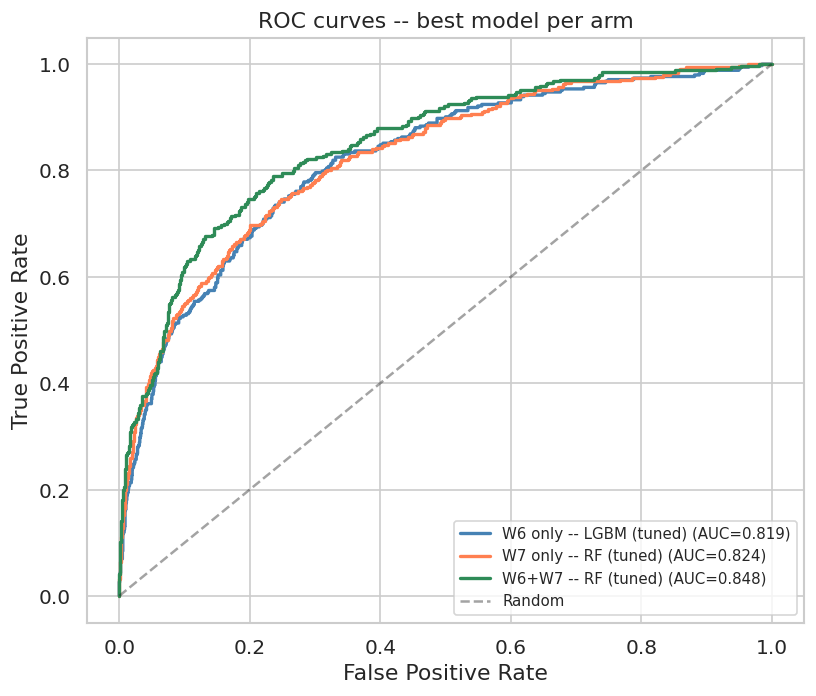

In [35]:
fig, ax = plt.subplots(figsize=(7, 6))
colors = {"W6 only":"steelblue","W7 only":"coral","W6+W7":"seagreen"}

for arm_name in ARM_COLS:
    arm_sub  = tuned_df[tuned_df["arm"] == arm_name]
    best_mod = arm_sub.loc[arm_sub["AUC"].idxmax(), "model"]
    pipe, cfg_cols = tuned_store[(arm_name, best_mod.replace(" (tuned)","").replace(" (baseline)",""))]
    _, X_te, _, y_te = splits[arm_name]
    y_proba = pipe.predict_proba(X_te[cfg_cols])[:, 1]
    fpr, tpr, _ = roc_curve(y_te, y_proba)
    auc_val = roc_auc_score(y_te, y_proba)
    ax.plot(fpr, tpr, label=f"{arm_name} -- {best_mod} (AUC={auc_val:.3f})",
            linewidth=2, color=colors[arm_name])

ax.plot([0,1],[0,1],"k--",alpha=0.4,label="Random")
ax.set(xlabel="False Positive Rate", ylabel="True Positive Rate",
       title="ROC curves -- best model per arm")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIRS["03_results"]/"roc_curves.png", bbox_inches="tight")
plt.show()


### 6.4 Precision-Recall curves

With ~19% prevalence, PR curves are more informative than ROC for the minority class. The no-skill baseline at 0.19 shows what a random classifier achieves.

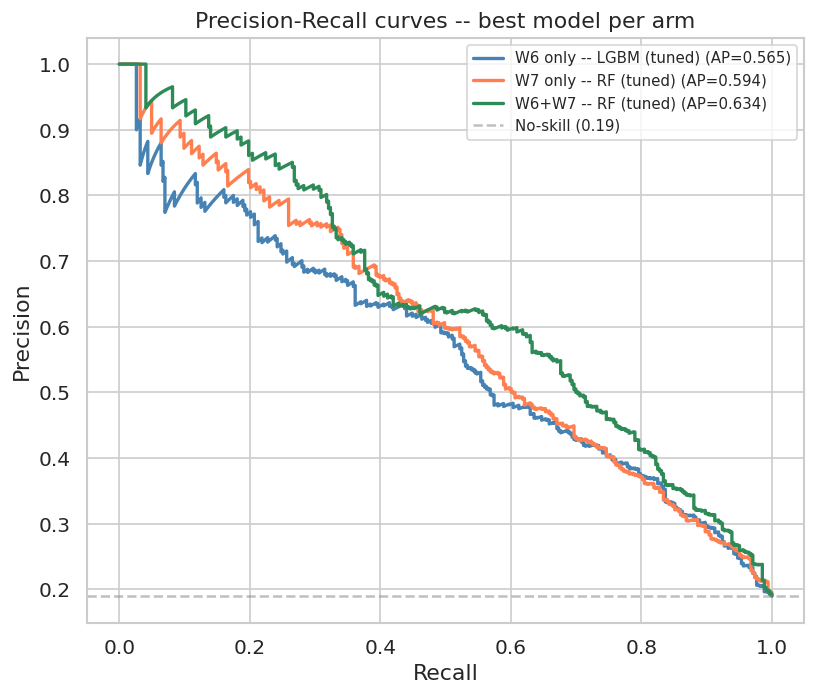

In [36]:
fig, ax = plt.subplots(figsize=(7, 6))

for arm_name in ARM_COLS:
    arm_sub  = tuned_df[tuned_df["arm"] == arm_name]
    best_mod = arm_sub.loc[arm_sub["AUC"].idxmax(), "model"]
    model_key = best_mod.replace(" (tuned)","").replace(" (baseline)","")
    pipe, cfg_cols = tuned_store[(arm_name, model_key)]
    _, X_te, _, y_te = splits[arm_name]
    y_proba = pipe.predict_proba(X_te[cfg_cols])[:, 1]
    prec, rec, _ = precision_recall_curve(y_te, y_proba)
    ap = average_precision_score(y_te, y_proba)
    ax.plot(rec, prec, label=f"{arm_name} -- {best_mod} (AP={ap:.3f})",
            linewidth=2, color=colors[arm_name])

ax.axhline(prev, color="grey", ls="--", alpha=0.5, label=f"No-skill ({prev:.2f})")
ax.set(xlabel="Recall", ylabel="Precision",
       title="Precision-Recall curves -- best model per arm")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIRS["03_results"]/"pr_curves.png", bbox_inches="tight")
plt.show()


### 6.5 Confusion matrices

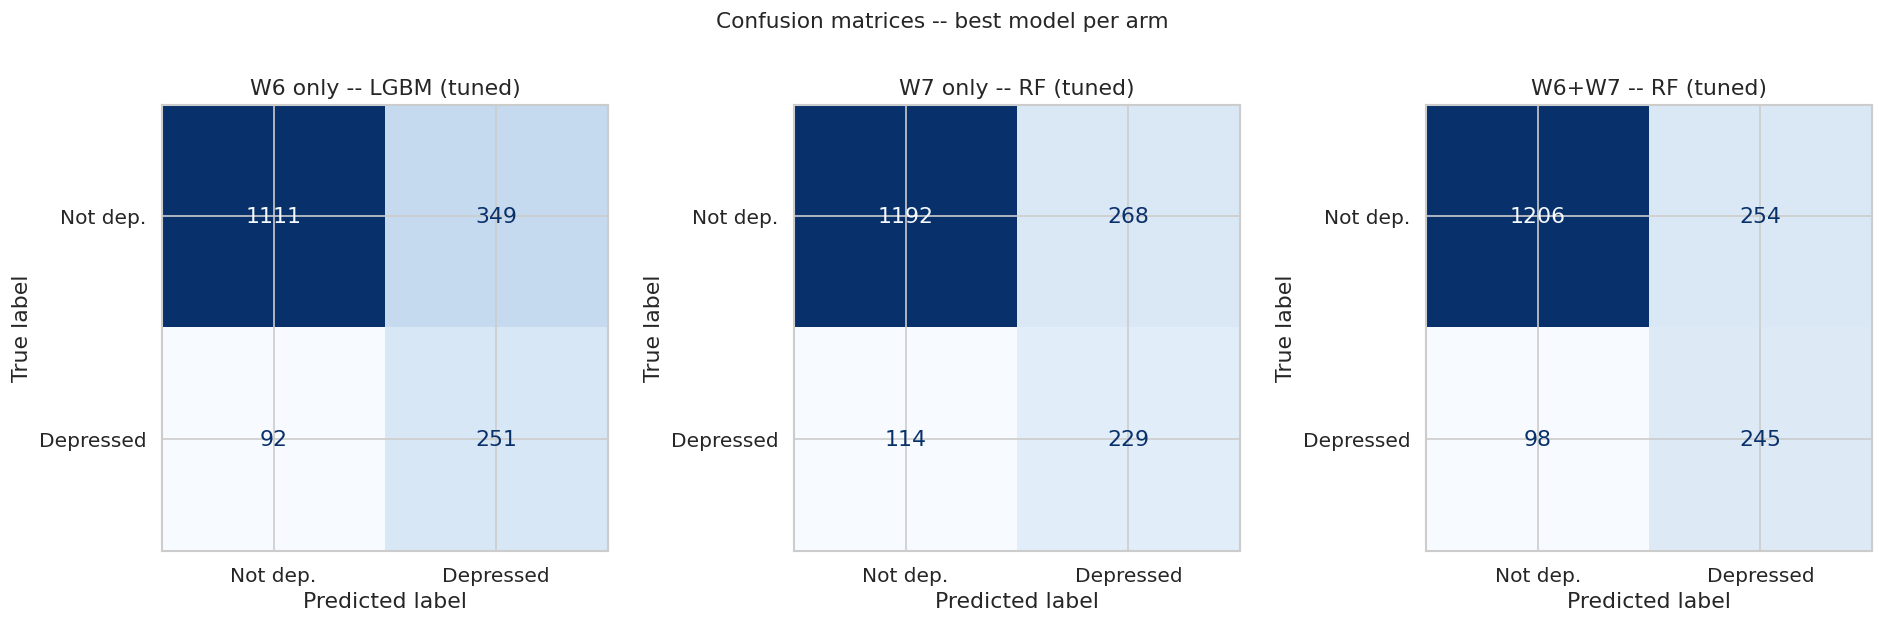

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, arm_name in zip(axes, ARM_COLS):
    arm_sub   = tuned_df[tuned_df["arm"] == arm_name]
    best_mod  = arm_sub.loc[arm_sub["AUC"].idxmax(), "model"]
    model_key = best_mod.replace(" (tuned)","").replace(" (baseline)","")
    pipe, cfg_cols = tuned_store[(arm_name, model_key)]
    _, X_te, _, y_te = splits[arm_name]
    y_pred = pipe.predict(X_te[cfg_cols])
    cm = confusion_matrix(y_te, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["Not dep.","Depressed"]).plot(
        ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"{arm_name} -- {best_mod}")

plt.suptitle("Confusion matrices -- best model per arm", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIRS["03_results"]/"confusion_matrices.png", bbox_inches="tight")
plt.show()


---
## 7. Interpretation (W6+W7 arm)

Interpretation focuses on the longitudinal arm (W6+W7) as the main model. Three tools answer **RQ3**:

1. Domain ablation -- leave-one-domain-out AUC drop
2. SHAP Act 1 -- which features drive predictions in the full model?
3. SHAP Act 2 -- what carries signal when prior depression history is removed?

The contrast between Acts 1 and 2 is the core finding for RQ3.


### 7.1 Domain ablation

  Remove prior_depression      : AUC=0.7712  drop=+0.0770
  Remove self_rated_health     : AUC=0.8431  drop=+0.0052
  Remove chronic_conditions    : AUC=0.8485  drop=-0.0002
  Remove mobility_function     : AUC=0.8492  drop=-0.0009
  Remove cognition             : AUC=0.8486  drop=-0.0003
  Remove socioeconomic         : AUC=0.8492  drop=-0.0009
  Remove social_housing        : AUC=0.8496  drop=-0.0013
  Remove lifestyle_digital     : AUC=0.8485  drop=-0.0002
  Remove demographics          : AUC=0.8478  drop=+0.0005


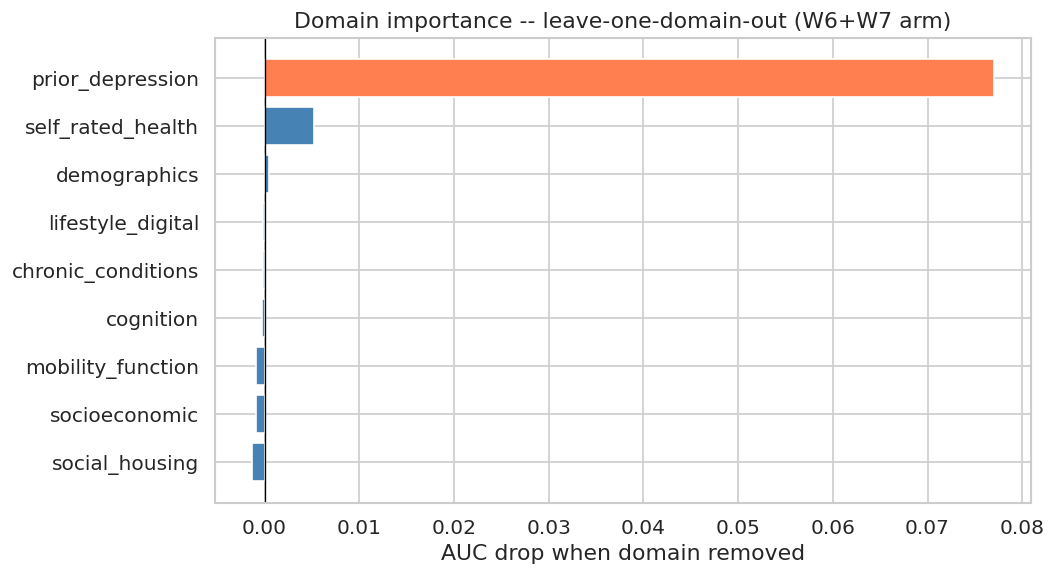

Saved: domain_ablation.png


In [38]:
arm_name  = "W6+W7"
best_cfg  = best_config_for_arm(results_df, arm_name)
cfg_cols  = [c for c in build_configs(ARM_COLS[arm_name])[best_cfg]
             if c in panel.columns]
X_tr, X_te, y_tr, y_te = splits[arm_name]

# Best tuned model for this arm
arm_sub   = tuned_df[tuned_df["arm"] == arm_name]
best_mod  = arm_sub.loc[arm_sub["AUC"].idxmax(), "model"]
model_key = best_mod.replace(" (tuned)","").replace(" (baseline)","")
best_pipe, _ = tuned_store[(arm_name, model_key)]

baseline_auc = roc_auc_score(y_te,
    best_pipe.predict_proba(X_te[cfg_cols])[:, 1])

# Build domains for this arm
arm_domains = {}
for dom_name, dom_cols in build_configs(ARM_COLS[arm_name]).items():
    pass  # configs not domains -- rebuild
arm_cols = ARM_COLS[arm_name]
domain_map = {
    "prior_depression":  [c for c in arm_cols if "cesd" in c.lower()],
    "self_rated_health": [c for c in arm_cols if any(p in c.lower()
                          for p in ["hehelf","heill","srh_hrs","llsill","hlimwrk"])],
    "chronic_conditions":[c for c in arm_cols if c.lower().startswith("hedia")],
    "mobility_function": [c for c in arm_cols if any(p in c.lower()
                          for p in ["mobility","adl_count","iadl_count",
                                    "functional_burden","hemob96","headl96"])],
    "cognition":         [c for c in arm_cols if any(p in c for p in ["memtotb","execnn"])],
    "socioeconomic":     [c for c in arm_cols if any(p in c.lower()
                          for p in ["ecpos","qual3","findiff","lackres","totwq5"])],
    "social_housing":    [c for c in arm_cols if any(p in c.lower()
                          for p in ["famtype","tenure","nsibs","ngrandch",
                                    "chinhh","chouthh","smokerstat"])],
    "lifestyle_digital": [c for c in arm_cols if any(p in c.lower()
                          for p in ["heact","scint","scptr"])],
    "demographics":      [c for c in arm_cols if any(c.startswith(p)
                          for p in ["age_","sex_","nonwhite_","marstat_","couple_"])],
}

abl_rows = [{"domain":"None (full)","n_features":len(cfg_cols),
              "AUC":round(baseline_auc,4),"AUC_drop":0.0}]

for dom_name, dom_cols in domain_map.items():
    remaining = [c for c in cfg_cols if c not in dom_cols]
    if not remaining: continue
    pipe_abl = copy.deepcopy(best_pipe)
    pipe_abl.fit(X_tr[remaining], y_tr)
    auc_abl  = roc_auc_score(y_te, pipe_abl.predict_proba(X_te[remaining])[:, 1])
    drop     = round(baseline_auc - auc_abl, 4)
    abl_rows.append({"domain":dom_name,"n_features":len(remaining),
                     "AUC":round(auc_abl,4),"AUC_drop":drop})
    print(f"  Remove {dom_name:22s}: AUC={auc_abl:.4f}  drop={drop:+.4f}")

abl_df = pd.DataFrame(abl_rows).sort_values("AUC_drop", ascending=False)
abl_df.to_csv(RES_DIR/"domain_ablation.csv", index=False)

plot_abl = abl_df[abl_df["domain"] != "None (full)"]
fig, ax  = plt.subplots(figsize=(9, 5))
cols_bar = ["coral" if d > 0.01 else "steelblue" for d in plot_abl["AUC_drop"]]
ax.barh(plot_abl["domain"], plot_abl["AUC_drop"], color=cols_bar, edgecolor="white")
ax.axvline(0, color="black", lw=0.8)
ax.set(xlabel="AUC drop when domain removed",
       title="Domain importance -- leave-one-domain-out (W6+W7 arm)")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIG_DIRS["04_interpretation"]/"domain_ablation.png", bbox_inches="tight")
plt.show()
print("Saved: domain_ablation.png")


### 7.2 SHAP -- Act 1 vs Act 2

Act 1 shows which features drive predictions in the full model. Act 2 removes all prior CES-D features and re-runs SHAP on the `no_cesd` config. The ranking shift between the two plots is the central finding for RQ3: once depression history is removed, self-rated health, mobility, and financial difficulty rise to the top.


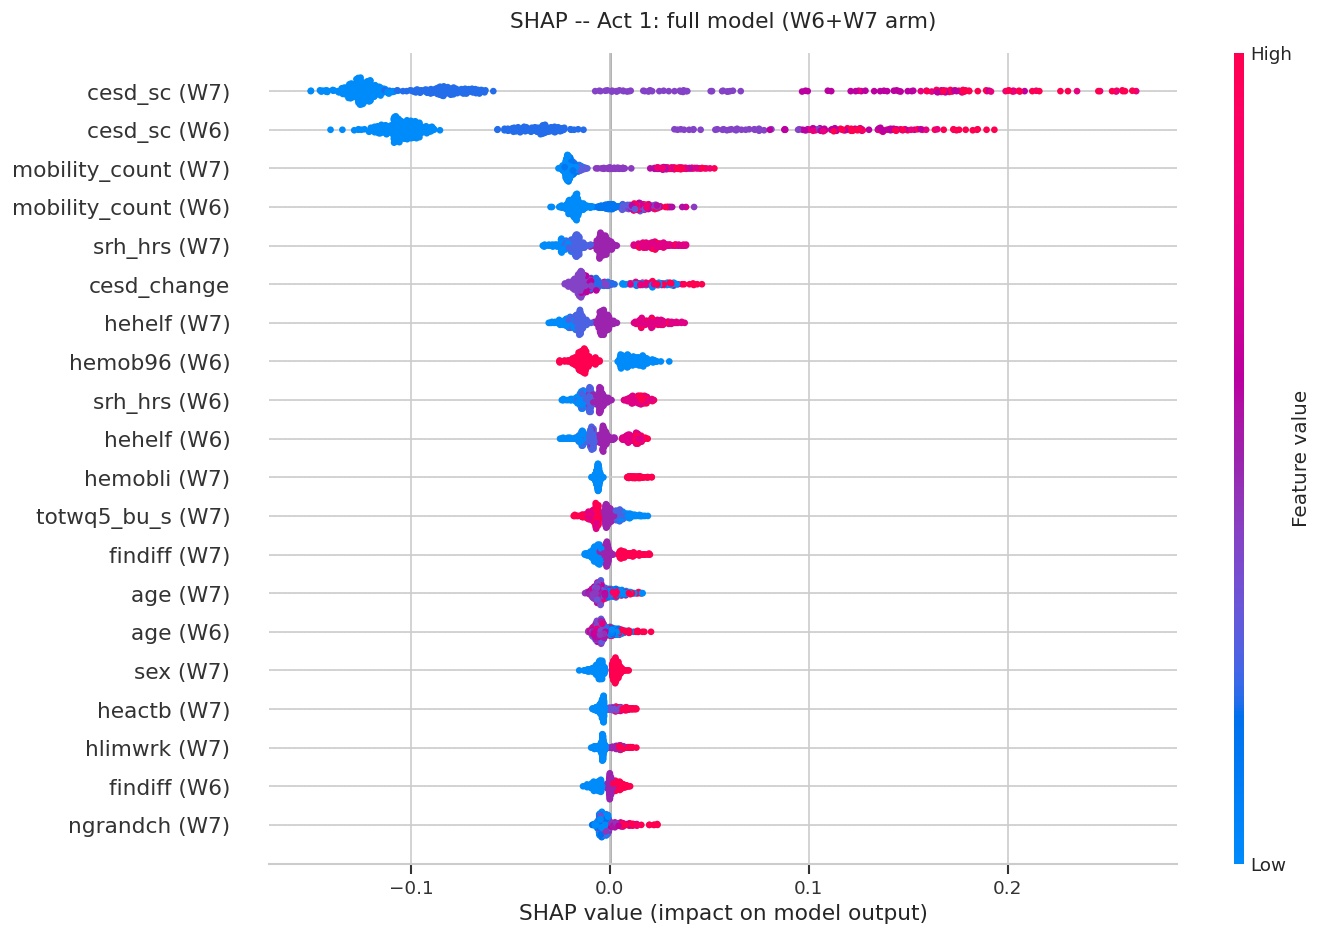

Saved: shap_act1_full.png


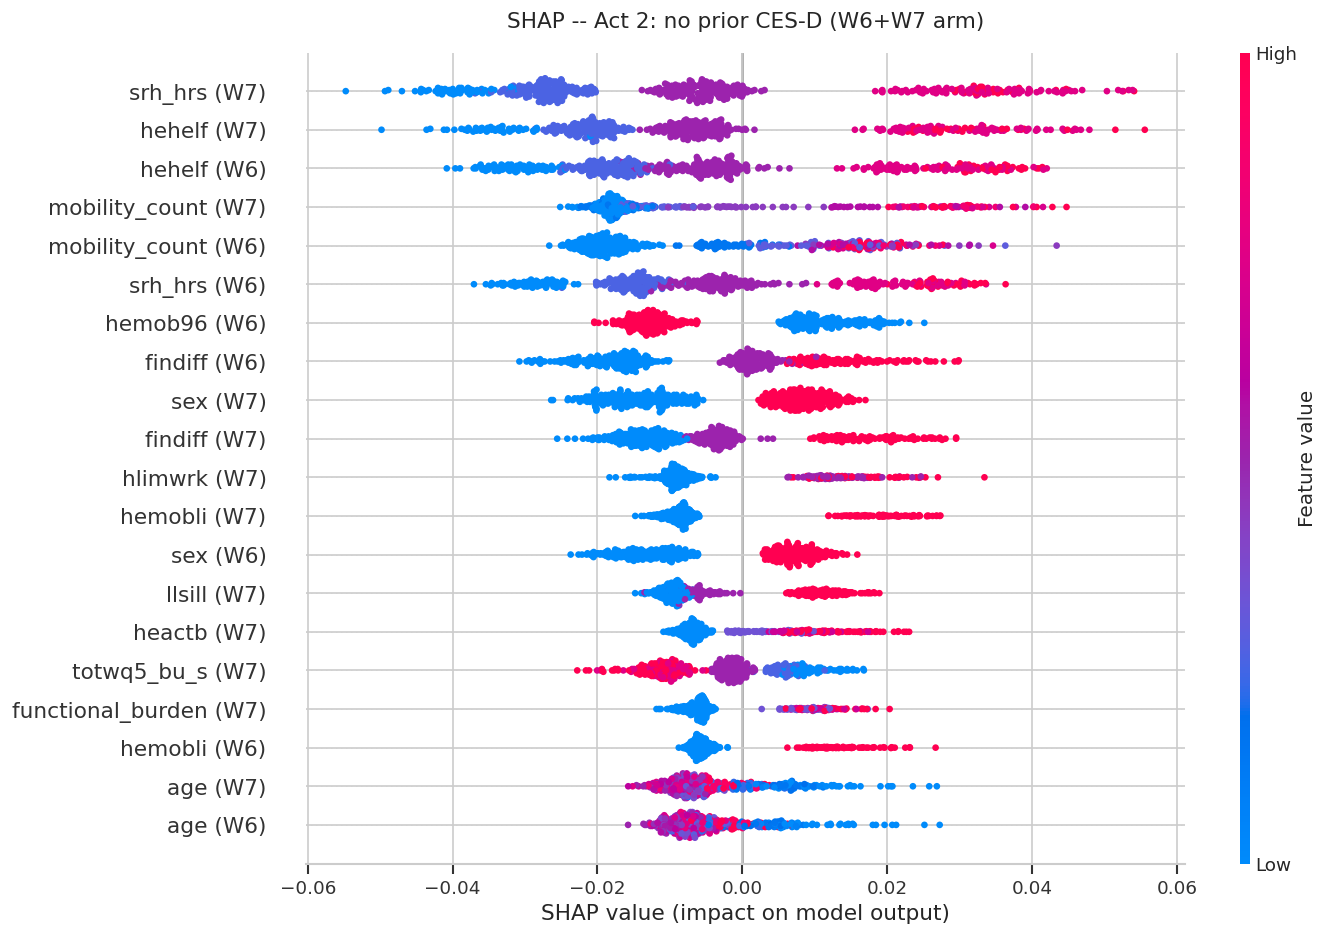

Saved: shap_act2_no_cesd.png


In [39]:
def run_shap_beeswarm(pipe, feat_cols, title, fpath, n_sample=500):
    imp     = pipe.named_steps["imp"]
    clf     = pipe.named_steps["clf"]
    _, X_te, _, _ = splits["W6+W7"]
    X_te_sub = X_te[feat_cols]
    X_imp    = pd.DataFrame(imp.transform(X_te_sub),
                             columns=feat_cols, index=X_te_sub.index)
    sample   = X_imp.sample(n=min(n_sample, len(X_imp)), random_state=SEED)
    explainer   = shap.TreeExplainer(clf)
    explanation = explainer(sample)
    sv = explanation.values[:,:,1] if explanation.values.ndim == 3 else explanation.values
    clean = [c.replace("_w6"," (W6)").replace("_w7"," (W7)") for c in feat_cols]
    plt.figure(figsize=(12, 8))
    shap.summary_plot(sv, sample, feature_names=clean, max_display=20,
                      show=False, plot_size=None)
    plt.title(title, fontsize=13, pad=15)
    plt.tight_layout()
    plt.savefig(fpath, bbox_inches="tight", dpi=150)
    plt.show()
    print(f"Saved: {fpath.name}")


# Act 1: full model
run_shap_beeswarm(
    best_pipe, cfg_cols,
    "SHAP -- Act 1: full model (W6+W7 arm)",
    FIG_DIRS["04_interpretation"]/"shap_act1_full.png"
)

# Act 2: no prior CES-D
no_cesd_cols = [c for c in cfg_cols
                if not any(p in c.lower() for p in ["cesd"])]
# Use fitted no_cesd RF from experiment loop
nc_key = ("W6+W7", "no_cesd", "RF")
if nc_key in fitted_store:
    nc_pipe, nc_cols = fitted_store[nc_key]
else:
    nc_pipe = copy.deepcopy(make_models(4)["RF"])
    X_tr, _, y_tr, _ = splits["W6+W7"]
    nc_pipe.fit(X_tr[no_cesd_cols], y_tr)
    nc_cols = no_cesd_cols

run_shap_beeswarm(
    nc_pipe, nc_cols,
    "SHAP -- Act 2: no prior CES-D (W6+W7 arm)",
    FIG_DIRS["04_interpretation"]/"shap_act2_no_cesd.png"
)


### 7.3 Calibration

Calibration checks whether predicted probabilities are reliable. A well-calibrated model that outputs 30% probability means roughly 30% of those individuals are actually depressed. Tree models are often overconfident; isotonic regression corrects this without changing AUC.

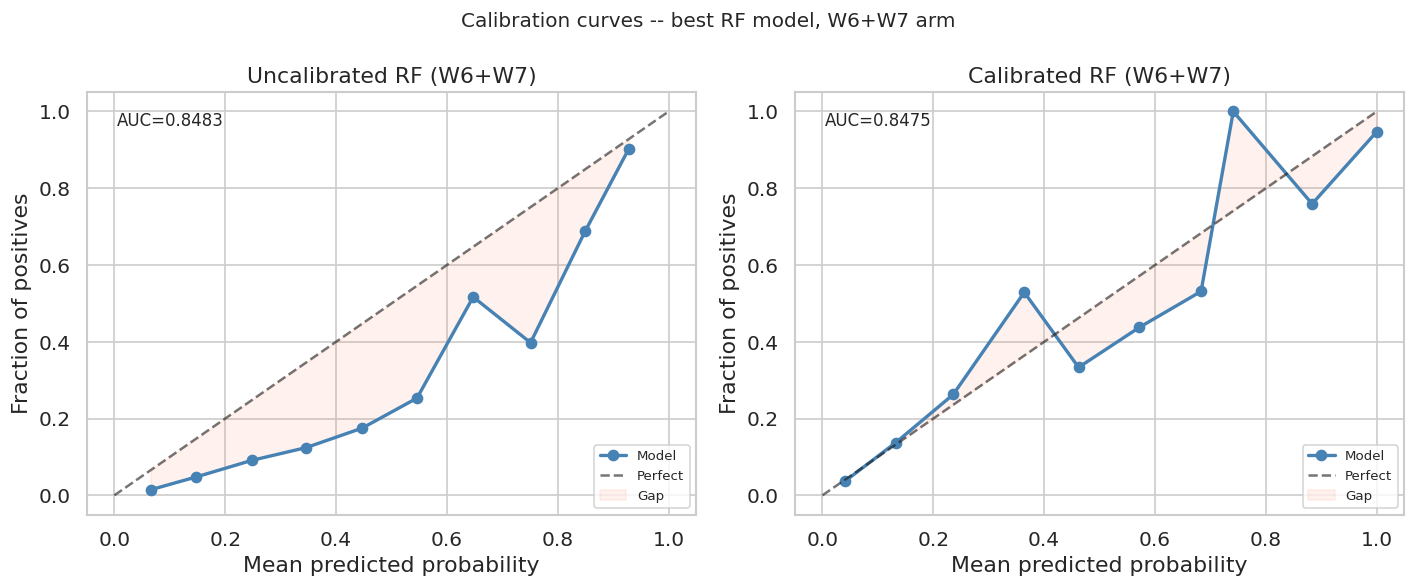

Note: isotonic calibration improves probability reliability with minimal AUC change.


In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

_, X_te, _, y_te = splits["W6+W7"]

for ax, label in zip(axes, ["Uncalibrated","Calibrated"]):
    if label == "Uncalibrated":
        y_proba = best_pipe.predict_proba(X_te[cfg_cols])[:, 1]
    else:
        X_tr_c, _, y_tr_c, _ = splits["W6+W7"]
        X_tc, X_cal, y_tc, y_cal = train_test_split(
            X_tr_c[cfg_cols], y_tr_c,
            test_size=0.2, stratify=y_tr_c, random_state=SEED)
        pipe_cal = copy.deepcopy(best_pipe)
        pipe_cal.fit(X_tc, y_tc)
        cal_pipe = CalibratedClassifierCV(pipe_cal, method="isotonic", cv="prefit")
        cal_pipe.fit(X_cal, y_cal)
        y_proba = cal_pipe.predict_proba(X_te[cfg_cols])[:, 1]

    pt, pp = calibration_curve(y_te, y_proba, n_bins=10)
    auc_v  = roc_auc_score(y_te, y_proba)
    ax.plot(pp, pt, marker="o", lw=2, color="steelblue", label="Model")
    ax.plot([0,1],[0,1],"k--",alpha=0.6, label="Perfect")
    ax.fill_between(pp, pt, pp, alpha=0.1, color="coral", label="Gap")
    ax.text(0.05, 0.92, f"AUC={auc_v:.4f}", transform=ax.transAxes, fontsize=10)
    ax.set(title=f"{label} RF (W6+W7)",
           xlabel="Mean predicted probability", ylabel="Fraction of positives")
    ax.legend(fontsize=8)

plt.suptitle("Calibration curves -- best RF model, W6+W7 arm", fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIRS["04_interpretation"]/"calibration.png", bbox_inches="tight")
plt.show()
print("Note: isotonic calibration improves probability reliability with minimal AUC change.")


---
## 8. Leakage Sensitivity

How much of the model's predictive power comes from prior CES-D scores versus other health and social features? This is not leakage in the technical sense (prior depression is a legitimate predictor) but it tests the clinical novelty claim: does the model capture something beyond "depressed people stay depressed"?

The analysis runs for all three arms, using the tuned best model per arm.


  W6 only    | With CES-D     : AUC=0.8192  F1b=0.5323
  W6 only    | Without CES-D  : AUC=0.7386  F1b=0.4373
  W7 only    | With CES-D     : AUC=0.8241  F1b=0.5452
  W7 only    | Without CES-D  : AUC=0.7692  F1b=0.4866
  W6+W7      | With CES-D     : AUC=0.8483  F1b=0.5819
  W6+W7      | Without CES-D  : AUC=0.7728  F1b=0.5080


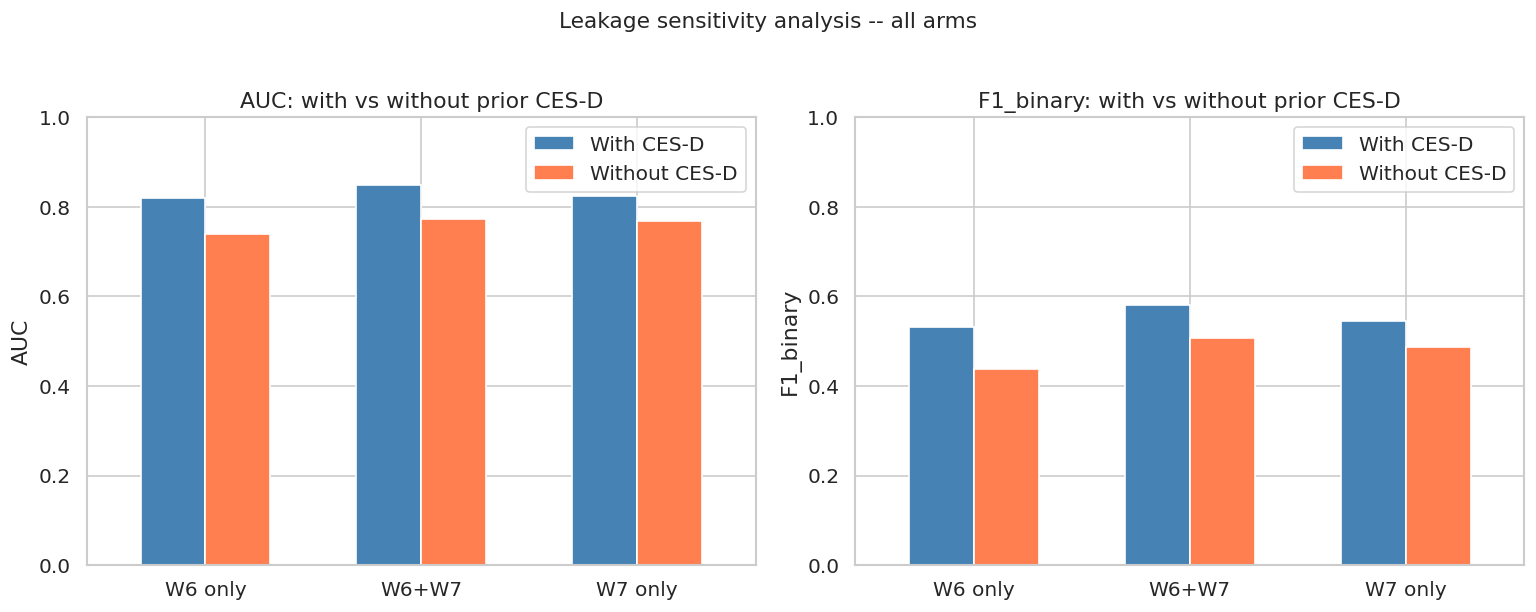

Saved: leakage_sensitivity.png


In [41]:
leak_rows = []

for arm_name in ARM_COLS:
    arm_sub   = tuned_df[tuned_df["arm"] == arm_name]
    best_mod  = arm_sub.loc[arm_sub["AUC"].idxmax(), "model"]
    model_key = best_mod.replace(" (tuned)","").replace(" (baseline)","")
    best_pipe_arm, cfg_c = tuned_store[(arm_name, model_key)]
    pw = int(splits[arm_name][2].eq(0).sum() / splits[arm_name][2].eq(1).sum())

    X_tr, X_te, y_tr, y_te = splits[arm_name]

    for label, include_cesd in [("With CES-D", True), ("Without CES-D", False)]:
        if include_cesd:
            cols = cfg_c
            pipe = best_pipe_arm
        else:
            cols = [c for c in cfg_c if "cesd" not in c.lower()]
            pipe = copy.deepcopy(make_models(pw)[model_key])
            pipe.fit(X_tr[cols], y_tr)

        m = eval_pipe(pipe, X_te[cols], y_te)
        leak_rows.append({"arm": arm_name, "cesd_included": label,
                           "model": model_key, "n_features": len(cols), **m})
        print(f"  {arm_name:10s} | {label:15s}: AUC={m['AUC']:.4f}  F1b={m['F1_binary']:.4f}")

leak_df = pd.DataFrame(leak_rows)
leak_df.to_csv(RES_DIR/"leakage_sensitivity.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, metric in zip(axes, ["AUC","F1_binary"]):
    pivot = leak_df.pivot_table(index="arm", columns="cesd_included", values=metric)
    pivot[["With CES-D","Without CES-D"]].plot.bar(
        ax=ax, color=["steelblue","coral"], edgecolor="white", width=0.6)
    ax.set_ylabel(metric)
    ax.set_title(f"{metric}: with vs without prior CES-D")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)
    ax.legend(title="")
    ax.set_ylim(0, 1)

plt.suptitle("Leakage sensitivity analysis -- all arms", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIRS["05_sensitivity"]/"leakage_sensitivity.png", bbox_inches="tight")
plt.show()
print("Saved: leakage_sensitivity.png")


---
## 9. Summary and Export

In [42]:
print("=" * 65)
print("ELSA Depression Prediction -- Pipeline Complete")
print("=" * 65)
print(f"  Participants:  {len(panel):,}  (W6 + W7 inner join, W8 outcome)")
print(f"  Outcome:       CES-D >= {CESD_CUTOFF} at Wave 8  ({prev:.1%} prevalence)")
print(f"  Arms:          W6 only / W7 only / W6+W7 combined")
print(f"  Models:        LR, RF, XGB, LGBM  (tuned via RandomizedSearchCV)")
print()
print("  Best tuned results by arm:")
best_rows = (tuned_df.sort_values("AUC", ascending=False)
             .groupby("arm").first().reset_index())
for _, r in best_rows.iterrows():
    print(f"    {r['arm']:10s}: AUC={r['AUC']:.3f}  F1_binary={r['F1_binary']:.3f}"
          f"  Recall={r['Recall']:.3f}  ({r['model']})")
print()
print("  Leakage check (W6+W7 arm, best model):")
lk = leak_df[leak_df["arm"]=="W6+W7"]
for _, r in lk.iterrows():
    print(f"    {r['cesd_included']:16s}: AUC={r['AUC']:.3f}")
print()
print("  References:")
print("    Banks et al. (2006). ELSA Wave 2. IFS.")
print("    Radloff (1977). CES-D Scale. Applied Psych Measurement, 1(3).")
print("    Steffick (2000). HRS affective functioning. DR-005.")
print("    Zhao et al. (2025). npj Digital Medicine.")
print("    Bergstra & Bengio (2012). JMLR, 13, 281-305.")
print("=" * 65)


ELSA Depression Prediction -- Pipeline Complete
  Participants:  7,211  (W6 + W7 inner join, W8 outcome)
  Outcome:       CES-D >= 3 at Wave 8  (19.0% prevalence)
  Arms:          W6 only / W7 only / W6+W7 combined
  Models:        LR, RF, XGB, LGBM  (tuned via RandomizedSearchCV)

  Best tuned results by arm:
    W6 only   : AUC=0.819  F1_binary=0.532  Recall=0.732  (LGBM (tuned))
    W6+W7     : AUC=0.848  F1_binary=0.582  Recall=0.714  (RF (tuned))
    W7 only   : AUC=0.824  F1_binary=0.545  Recall=0.668  (RF (tuned))

  Leakage check (W6+W7 arm, best model):
    With CES-D      : AUC=0.848
    Without CES-D   : AUC=0.773

  References:
    Banks et al. (2006). ELSA Wave 2. IFS.
    Radloff (1977). CES-D Scale. Applied Psych Measurement, 1(3).
    Steffick (2000). HRS affective functioning. DR-005.
    Zhao et al. (2025). npj Digital Medicine.
    Bergstra & Bengio (2012). JMLR, 13, 281-305.


### 9.1 Copy outputs to Drive

In [43]:
import shutil
from pathlib import Path

dest = Path("/content/drive/MyDrive/ELSA_Submission_Outputs")
if dest.exists():
    shutil.rmtree(dest)
shutil.copytree(Path("/content/outputs"), dest)
print(f"Outputs copied to: {dest}")
print("Contents:")
for f in sorted(dest.rglob("*")):
    if f.is_file():
        print(f"  {f.relative_to(dest)}")


Outputs copied to: /content/drive/MyDrive/ELSA_Submission_Outputs
Contents:
  figures/01_data/outcome_distribution.png
  figures/02_experiments/auc_all_arms_configs.png
  figures/03_results/arm_comparison.png
  figures/03_results/confusion_matrices.png
  figures/03_results/pr_curves.png
  figures/03_results/roc_curves.png
  figures/04_interpretation/calibration.png
  figures/04_interpretation/domain_ablation.png
  figures/04_interpretation/shap_act1_full.png
  figures/04_interpretation/shap_act2_no_cesd.png
  figures/05_sensitivity/leakage_sensitivity.png
  results/all_experiments.csv
  results/domain_ablation.csv
  results/leakage_sensitivity.csv
  results/tuned_models.csv
